# A/B-тестирование: стоит ли переносить игровой барьер?
## Cookie Cats · control / treatment

**Бизнес-задача:** выяснить, помогает ли перенос первого игрового барьера с
30-го на 40-й уровень удерживать новых игроков.

**Маршрут:** данные → EDA → H₀/H₁ → выбор теста → p-value →
доверительный интервал → решение для бизнеса.

Это учебный ретроспективный разбор готового эксперимента.
Основную метрику для этого проекта выбираем по бизнес-вопросу: **retention_7**,
то есть долю игроков, вернувшихся на 7-й день после установки.
Мы не утверждаем, что она была заранее зарегистрирована авторами эксперимента.
В реальном тесте метрику, размер выборки, срок и правила решения фиксируют до запуска.

## 1. Данные и дизайн эксперимента

Используем публичный набор Cookie Cats из учебного проекта DataCamp.
CSV сохранён локально; источник, версия и контрольная сумма находятся в
файлах data/README.md и data/source.json.
В [карточке датасета](https://www.kaggle.com/datasets/mursideyarkin/mobile-games-ab-testing-cookie-cats)
описано случайное назначение игроков в варианты.

| Поле | Значение |
|:--|:--|
| userid | Идентификатор игрока; единица рандомизации и анализа |
| version | gate_30 — control; gate_40 — treatment |
| sum_gamerounds | Количество сыгранных раундов; по карточке датасета — за первые 14 дней |
| retention_1 | Возврат на 1-й день, True / False; только описательная метрика |
| retention_7 | Возврат на 7-й день, True / False; основная метрика |

Игровой барьер требует ожидания или покупки, чтобы продолжить прохождение.
Идея изменения: дать игроку больше времени до первой паузы.
Отсрочка может как улучшить вовлечение, так и ухудшить возвращаемость — поэтому
проверяем изменение в обе стороны.

Анализируем **всех назначенных игроков** по исходной группе, включая тех, кто
не дошёл до барьера или не сыграл ни одного раунда. Отбор по действиям после
назначения может исказить эффект изменения.

In [1]:
from pathlib import Path
import hashlib
import json
import os
import sys
import importlib.metadata

ROOT = Path.cwd()
if not (ROOT / "data/cookie_cats.csv").exists():
    raise FileNotFoundError("Запустите ноутбук из корня проекта: рядом должна быть папка data.")

os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".cache/matplotlib"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy import stats
from statsmodels.stats.proportion import (
    proportions_ztest,
    proportion_confint,
    confint_proportions_2indep,
)
from IPython.display import display, Markdown

%matplotlib inline
ALPHA = 0.05
PRIMARY_METRIC = "retention_7"
GROUPS = ["control", "treatment"]
COLORS = ["#236B8E", "#D57836"]
REPORTS = ROOT / "reports"
FIGURES = REPORTS / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.dpi": 160,
})
pd.set_option("display.max_columns", 12)
pd.set_option("display.float_format", "{:.4f}".format)

versions = {name: importlib.metadata.version(name) for name in
            ["numpy", "pandas", "scipy", "statsmodels", "matplotlib"]}
print("Python:", sys.version.split()[0])
print("Библиотеки:", versions)

Matplotlib is building the font cache; this may take a moment.


Python: 3.9.6
Библиотеки: {'numpy': '2.0.2', 'pandas': '2.2.3', 'scipy': '1.13.1', 'statsmodels': '0.14.4', 'matplotlib': '3.9.4'}


In [2]:
data_path = ROOT / "data/cookie_cats.csv"
data_hash = hashlib.sha256(data_path.read_bytes()).hexdigest()
metadata = json.loads((ROOT / "data/source.json").read_text(encoding="utf-8"))
assert data_hash == metadata["sha256"], "CSV изменён относительно сохранённого источника."

raw = pd.read_csv(data_path)
display(raw.head())
print(f"Размер: {len(raw):,} строк × {raw.shape[1]} столбцов")

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


Размер: 90,189 строк × 5 столбцов


## 2. EDA: качество данных и сравнение групп

Сначала проверим полноту и структуру данных: пропуски, повторные строки,
повторные идентификаторы и допустимые значения. Ничего не удаляем автоматически:
ошибки входных данных должны остановить анализ и потребовать разбирательства.

In [3]:
expected_columns = {"userid", "version", "sum_gamerounds", "retention_1", "retention_7"}
assert set(raw.columns) == expected_columns, "Неожиданная схема данных."

quality = pd.DataFrame({
    "Проверка": ["Пропуски во всех полях", "Полные дубликаты",
                 "Повторные userid", "Отрицательное число раундов"],
    "Количество": [int(raw.isna().sum().sum()), int(raw.duplicated().sum()),
                   int(raw["userid"].duplicated().sum()),
                   int(raw["sum_gamerounds"].lt(0).sum())],
})
display(quality)
display(raw.dtypes.rename("Тип данных").to_frame())

assert not raw.isna().any().any(), "Есть пропуски."
assert raw["userid"].is_unique, "Игрок встречается более одного раза."
assert set(raw["version"]) == {"gate_30", "gate_40"}, "Неизвестный вариант."
assert pd.api.types.is_integer_dtype(raw["sum_gamerounds"])
assert raw["sum_gamerounds"].ge(0).all()
for metric in ["retention_1", "retention_7"]:
    assert pd.api.types.is_bool_dtype(raw[metric]), f"{metric}: ожидается True / False."

df = raw.copy()
df["group"] = df["version"].map({"gate_30": "control", "gate_40": "treatment"})
df[["retention_1", "retention_7"]] = df[["retention_1", "retention_7"]].astype(int)
assert len(df) == len(raw), "Все назначенные игроки должны остаться в анализе."
print("Проверки пройдены. Строк удалено: 0.")

,Проверка,Количество
0,Пропуски во всех полях,0
1,Полные дубликаты,0
2,Повторные userid,0
3,Отрицательное число раундов,0


,Тип данных
userid,int64
version,object
sum_gamerounds,int64
retention_1,bool
retention_7,bool


Проверки пройдены. Строк удалено: 0.


In [4]:
summary = df.groupby("group").agg(
    users=("userid", "size"),
    retained_d1=("retention_1", "sum"),
    retained_d7=("retention_7", "sum"),
    retention_d1=("retention_1", "mean"),
    retention_d7=("retention_7", "mean"),
    mean_rounds=("sum_gamerounds", "mean"),
    median_rounds=("sum_gamerounds", "median"),
).reindex(GROUPS)
summary["share"] = summary["users"] / len(df)

display(summary.style.format({
    "users": "{:,.0f}", "retained_d1": "{:,.0f}", "retained_d7": "{:,.0f}",
    "retention_d1": "{:.2%}", "retention_d7": "{:.2%}", "share": "{:.2%}",
    "mean_rounds": "{:.2f}", "median_rounds": "{:.0f}",
}))
display(df.groupby("group")["sum_gamerounds"].describe(
    percentiles=[0.5, 0.9, 0.99]).reindex(GROUPS))
display(df.nlargest(3, "sum_gamerounds"))

,users,retained_d1,retained_d7,retention_d1,retention_d7,mean_rounds,median_rounds,share
group,,,,,,,,
control,"44,700","20,034","8,502",44.82%,19.02%,52.46,17,49.56%
treatment,"45,489","20,119","8,279",44.23%,18.20%,51.30,16,50.44%


,count,mean,std,min,50%,90%,99%,max
group,,,,,,,,
control,44700.0000,52.4563,256.7164,0.0000,17.0000,135.0000,493.0000,49854.0000
treatment,45489.0000,51.2988,103.2944,0.0000,16.0000,134.0000,492.1200,2640.0000


,userid,version,sum_gamerounds,retention_1,retention_7,group
57702,6390605,gate_30,49854,0,1,control
7912,871500,gate_30,2961,1,1,control
29417,3271615,gate_40,2640,1,0,treatment


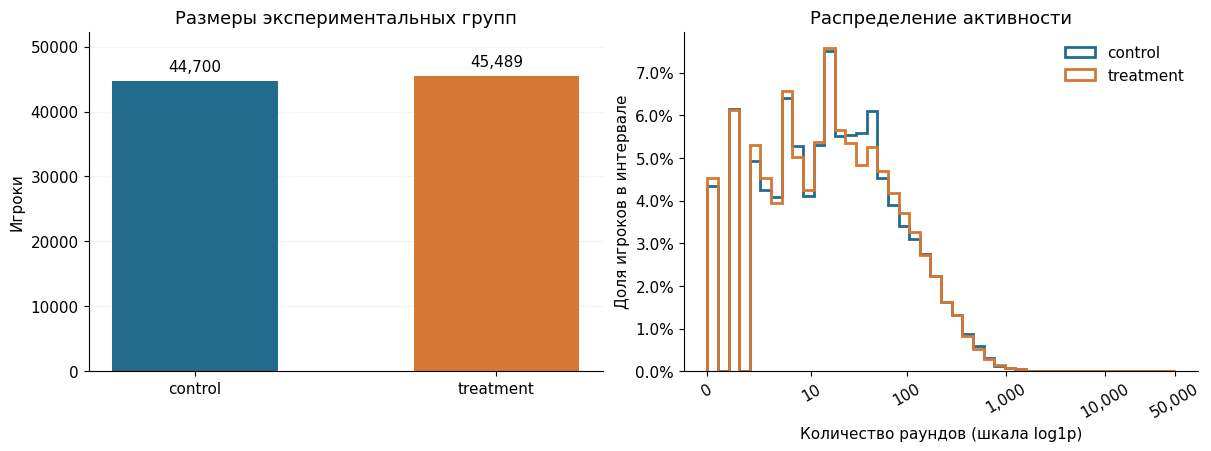

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), layout="constrained")
bars = axes[0].bar(GROUPS, summary["users"], color=COLORS, width=0.55)
axes[0].bar_label(bars, labels=[f"{n:,}" for n in summary["users"]], padding=5)
axes[0].set(title="Размеры экспериментальных групп", ylabel="Игроки")
axes[0].set_ylim(0, summary["users"].max() * 1.15)
axes[0].grid(axis="y", alpha=0.15)
axes[0].set_axisbelow(True)

# log1p сохраняет нулевые значения и показывает весь диапазон без удаления выбросов.
bins = np.linspace(0, np.log1p(df["sum_gamerounds"].max()), 45)
for group, color in zip(GROUPS, COLORS):
    values = np.log1p(df.loc[df["group"].eq(group), "sum_gamerounds"])
    axes[1].hist(values, bins=bins, weights=np.ones(len(values)) / len(values),
                 histtype="step", linewidth=2, color=color, label=group)
axes[1].set(title="Распределение активности", xlabel="Количество раундов (шкала log1p)",
            ylabel="Доля игроков в интервале")
ticks = np.array([0, 10, 100, 1000, 10000, 50000])
axes[1].set_xticks(np.log1p(ticks), [f"{v:,}" for v in ticks], rotation=30)
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].legend(frameon=False)
fig.savefig(FIGURES / "01_eda.png", bbox_inches="tight")
plt.show()

В активности есть длинный правый хвост: среднее чувствительно к очень большим
значениям. Максимальную запись стоит проверить по журналам событий.
В этом проекте её сохраняем: основная метрика бинарная, и число раундов не
увеличивает вес игрока в расчёте удержания. Логарифмическая шкала нужна только
для отображения; исходные данные не преобразуем и не фильтруем.

Различия в количестве раундов и retention_1 описываем без отдельных
проверок значимости. Это метрики после воздействия, поэтому их близость
или различие не доказывает качество рандомизации.

### Проверка соотношения групп — SRM

Для диагностической проверки принимаем **плановое распределение 50 / 50**.
Это допущение проекта: протокол с заданной долей трафика в CSV отсутствует.
Проверяем χ²-тестом согласия, совместимы ли размеры групп с таким распределением.
Для этой диагностики используем порог 0,01.

SRM проверяет только численность групп. Даже высокий p-value не доказывает,
что рандомизация и сбор событий работали без ошибок.

При сигнале SRM дальнейшие расчёты сохраняем как учебные и предварительные;
окончательный причинный вывод откладываем до проверки плановых долей и логов.

In [6]:
expected_sizes = np.repeat(len(df) / 2, 2)
srm_stat, srm_p = stats.chisquare(summary["users"].to_numpy(), f_exp=expected_sizes)
print(f"SRM: χ² = {srm_stat:.4f}; p-value = {srm_p:.4f}")
srm_flag = bool(srm_p < 0.01)
if srm_flag:
    print("Есть сигнал SRM при допущении 50/50. Проверьте плановые доли и сбор данных.")
    print("Ниже — предварительные расчёты; окончательный причинный вывод делать рано.")
else:
    print("При допущении 50/50 значимого отклонения численности групп не обнаружено.")

SRM: χ² = 6.9024; p-value = 0.0086
Есть сигнал SRM при допущении 50/50. Проверьте плановые доли и сбор данных.
Ниже — предварительные расчёты; окончательный причинный вывод делать рано.


## 3. Формулировка H₀ / H₁

Пусть p_control и p_treatment — вероятности возврата на 7-й день
в соответствующих вариантах. Интересующий эффект:

**Δ = p_treatment − p_control.**

- **H₀: Δ = 0.** Перенос барьера не меняет вероятность возврата на 7-й день.
- **H₁: Δ ≠ 0.** Перенос барьера меняет эту вероятность.
- Уровень значимости основной проверки **α = 0,05**.
- Альтернатива двусторонняя: важны и улучшение, и ухудшение.

При p-value < α отвергаем H₀. Иначе оснований отвергнуть H₀ недостаточно —
это не доказательство равенства вариантов.

Одна основная метрика означает одну основную проверку. Retention_1 остаётся
описательной: мы не выбираем «удачный» результат из нескольких тестов.
SRM — отдельная проверка качества эксперимента, а не поиск продуктового эффекта.

## 4. Почему z-тест двух долей

Результат для каждого игрока равен 0 или 1; сравниваем доли успехов в двух
независимых группах. Для большой выборки подходит
[двухвыборочный z-тест долей](https://www.statsmodels.org/stable/generated/statsmodels.stats.proportion.proportions_ztest.html).

Проверим, что ожидаемых успехов и неуспехов при H₀ достаточно для нормального
приближения. Нормальность исходной бинарной метрики не требуется.

Предположения: независимость игроков, случайное назначение, отсутствие влияния
групп друг на друга и полное окно наблюдения до 7-го дня для каждого игрока.
Уникальность идентификаторов проверяется по CSV; остальные условия полностью
подтвердить без протокола и журналов эксперимента нельзя.

Под H₀ используем объединённую долю p_pool:

**z = (p̂_treatment − p̂_control) / √[p_pool × (1 − p_pool) ×
(1/n_treatment + 1/n_control)].**

In [7]:
# Во всех расчётах порядок одинаковый: treatment минус control.
n_t = int(summary.loc["treatment", "users"])
n_c = int(summary.loc["control", "users"])
x_t = int(summary.loc["treatment", "retained_d7"])
x_c = int(summary.loc["control", "retained_d7"])
p_t, p_c = x_t / n_t, x_c / n_c
delta = p_t - p_c
relative_lift = delta / p_c

pooled = (x_t + x_c) / (n_t + n_c)
expected = pd.DataFrame({
    "Ожидаемые возвраты при H0": [n_c * pooled, n_t * pooled],
    "Ожидаемые невозвраты при H0": [n_c * (1 - pooled), n_t * (1 - pooled)],
}, index=GROUPS)
display(expected)
assert expected.to_numpy().min() >= 10, "Малые частоты: требуется другой метод."

z_stat, p_value = proportions_ztest(
    count=[x_t, x_c],
    nobs=[n_t, n_c],
    value=0,
    alternative="two-sided",
    prop_var=False,
)
print(f"Control:   {x_c:,} / {n_c:,} = {p_c:.4%}")
print(f"Treatment: {x_t:,} / {n_t:,} = {p_t:.4%}")
print(f"z = {z_stat:.4f}; p-value = {p_value:.6f}")
print(f"Разница: {delta * 100:+.4f} п.п.; относительное изменение: {relative_lift:+.2%}")
print("При выполнении предпосылок H0 отвергаем." if p_value < ALPHA
      else "Недостаточно оснований отвергнуть H0.")
if srm_flag:
    print("Это номинальный p-value: сигнал SRM ещё не объяснён.")

,Ожидаемые возвраты при H0,Ожидаемые невозвраты при H0
control,8317.0974,36382.9026
treatment,8463.9026,37025.0974


Control:   8,502 / 44,700 = 19.0201%
Treatment: 8,279 / 45,489 = 18.2000%
z = -3.1644; p-value = 0.001554
Разница: -0.8201 п.п.; относительное изменение: -4.31%
При выполнении предпосылок H0 отвергаем.
Это номинальный p-value: сигнал SRM ещё не объяснён.


**Как понимать p-value.** Если H₀ верна и предположения теста выполнены,
p-value — вероятность получить столь же или более экстремальную тестовую
статистику в любую сторону. Это не вероятность истинности H₀ и не вероятность
того, что результат «случайный».

Процентные пункты и проценты отвечают на разные вопросы: разница долей,
умноженная на 100, — это **п.п.**; разница, делённая на долю control, —
**относительное изменение**.

## 5. Доверительный интервал

Для эффекта Δ строим 95%-й
[интервал Ньюкомба на основе интервалов Уилсона](https://www.statsmodels.org/stable/generated/statsmodels.stats.proportion.confint_proportions_2indep.html).
Для каждой отдельной группы на графике используем интервал Уилсона.
Основной вывод о разнице делаем по **интервалу Δ**, а не по пересечению
интервалов отдельных групп.

Это частотный интервал: при многократном повторении процедуры примерно 95%
таких интервалов покрывали бы истинную разницу. Он не означает, что
фиксированный параметр с вероятностью 95% лежит внутри уже рассчитанных границ.

Z-тест и интервал Ньюкомба используют разные приближения; интервал не является
точной инверсией выбранного теста. Здесь проверим, что их выводы согласуются.

95% ДИ разницы treatment − control: [-1.3282; -0.3121] п.п.
Ноль входит в интервал: False


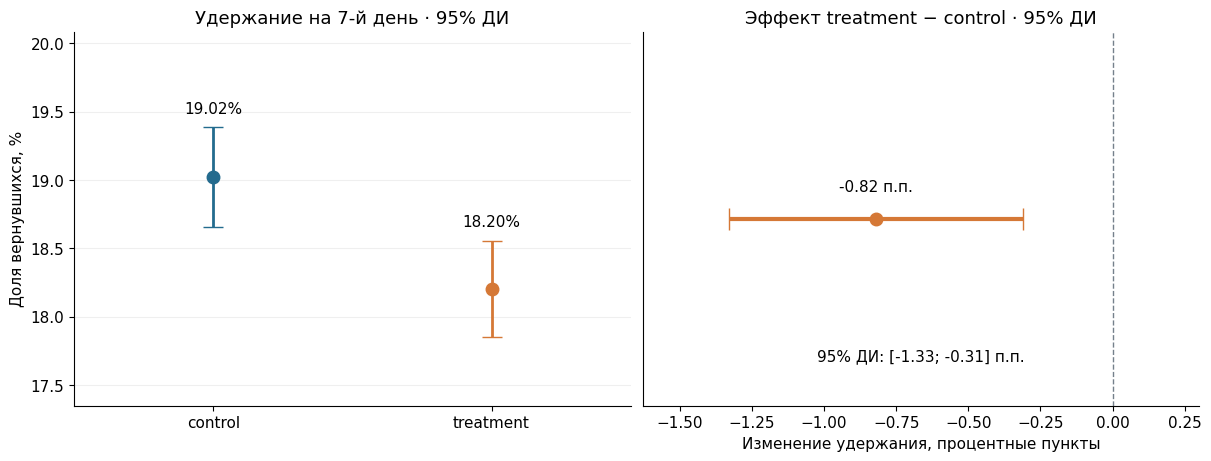

In [8]:
ci_low, ci_high = confint_proportions_2indep(
    count1=x_t, nobs1=n_t,
    count2=x_c, nobs2=n_c,
    compare="diff", method="newcomb", alpha=ALPHA,
)
group_low, group_high = proportion_confint(
    count=summary["retained_d7"].to_numpy(),
    nobs=summary["users"].to_numpy(),
    alpha=ALPHA,
    method="wilson",
)
print(f"95% ДИ разницы treatment − control: [{ci_low * 100:+.4f}; {ci_high * 100:+.4f}] п.п.")
print("Ноль входит в интервал:", bool(ci_low <= 0 <= ci_high))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout="constrained")
rates = summary["retention_d7"].to_numpy()
for i, color in enumerate(COLORS):
    axes[0].errorbar(i, rates[i] * 100,
        yerr=[[100 * (rates[i] - group_low[i])], [100 * (group_high[i] - rates[i])]],
        fmt="o", markersize=9, capsize=7, color=color, linewidth=2)
    axes[0].annotate(f"{rates[i]:.2%}", (i, group_high[i] * 100),
                     xytext=(0, 10), textcoords="offset points", ha="center")
axes[0].set_xticks([0, 1], GROUPS)
axes[0].set_xlim(-0.5, 1.5)
axes[0].set_ylim(group_low.min() * 100 - 0.5, group_high.max() * 100 + 0.7)
axes[0].set(title="Удержание на 7-й день · 95% ДИ", ylabel="Доля вернувшихся, %")
axes[0].grid(axis="y", alpha=0.2)

axes[1].axvline(0, color="#75808B", linestyle="--", linewidth=1)
axes[1].errorbar(delta * 100, 0,
    xerr=[[100 * (delta - ci_low)], [100 * (ci_high - delta)]],
    fmt="o", color=COLORS[1], capsize=8, markersize=9, linewidth=3)
axes[1].set_yticks([])
axes[1].set_ylim(-0.7, 0.7)
axes[1].set_xlim(min(ci_low * 100 - 0.3, -0.2), max(ci_high * 100 + 0.3, 0.3))
axes[1].set(title="Эффект treatment − control · 95% ДИ",
            xlabel="Изменение удержания, процентные пункты")
axes[1].annotate(f"{delta * 100:+.2f} п.п.", (delta * 100, 0),
                xytext=(0, 20), textcoords="offset points", ha="center")
axes[1].text(0.5, 0.12, f"95% ДИ: [{ci_low * 100:+.2f}; {ci_high * 100:+.2f}] п.п.",
             transform=axes[1].transAxes, ha="center")
fig.savefig(FIGURES / "02_retention_effect.png", bbox_inches="tight")
plt.show()

## 6. Проверка расчётов

Сверим z-статистику с формулой и с χ²-тестом независимости для таблицы 2 × 2
**без поправки Йейтса**: в этой постановке χ² = z².
Это проверка вычислений на тех же данных, а не новое независимое подтверждение эффекта.

In [9]:
standard_error_h0 = np.sqrt(pooled * (1 - pooled) * (1 / n_t + 1 / n_c))
z_manual = delta / standard_error_h0
table = np.array([[x_t, n_t - x_t], [x_c, n_c - x_c]])
chi2, chi2_p, _, _ = stats.chi2_contingency(table, correction=False)
assert np.isclose(z_stat, z_manual)
assert np.isclose(chi2, z_stat ** 2)
assert np.isclose(chi2_p, p_value)
assert ci_low <= delta <= ci_high
assert 0 <= p_value <= 1
assert (p_value < ALPHA) == (not ci_low <= 0 <= ci_high)
print("Формула, z-тест, χ²-тест и направление доверительного интервала согласуются.")

Формула, z-тест, χ²-тест и направление доверительного интервала согласуются.


## 7. Вывод для бизнеса

Переведём эффект в число вернувшихся игроков на 10 000 новых установок.
Это масштабирование разницы вероятностей при сопоставимой аудитории,
**не прогноз случайного числа возвратов** в конкретной будущей когорте.
Интервал показывает неопределённость средней разницы, а не прогнозный интервал.

Денежную оценку не рассчитываем: в CSV нет выручки, платежей, LTV или стоимости
внедрения. Порог минимального полезного эффекта также не задан владельцем продукта.

In [10]:
base = 10_000
effect_per_10k = delta * base
ci_per_10k = np.array([ci_low, ci_high]) * base
if p_value < ALPHA and ci_high < 0:
    recommendation = (
        "Сохранить барьер на 30-м уровне и не внедрять перенос на 40-й уровень "
        "при цели улучшить удержание на 7-й день."
    )
    interpretation = "Удержание в treatment статистически значимо ниже, чем в control."
elif p_value < ALPHA and ci_low > 0:
    recommendation = (
        "Рассмотреть внедрение после проверки практической ценности эффекта, "
        "выручки и остальных защитных метрик."
    )
    interpretation = "Удержание в treatment статистически значимо выше, чем в control."
else:
    recommendation = (
        "Не объявлять вариант победителем; решение о новом тесте принимать "
        "по допустимому эффекту и заранее рассчитанному объёму выборки."
    )
    interpretation = "Данных недостаточно, чтобы отвергнуть H0."

if srm_flag:
    recommendation = (
        "Сохранить текущий вариант control и отложить внедрение treatment. "
        "Сначала проверить плановые доли трафика, рандомизацию и полноту событий: "
        "обнаружен сигнал SRM при допущении 50/50."
    )
    interpretation = (
        "При выполнении предпосылок номинальный z-тест указывает на снижение удержания "
        "в treatment. Из-за неразобранного сигнала SRM этот вывод предварительный: "
        "наблюдаемую разницу пока нельзя уверенно приписывать переносу барьера."
    )
srm_description = (
    "есть диагностический сигнал при пороге 0,01" if srm_flag
    else "значимого отклонения при пороге 0,01 не обнаружено"
)

business_summary = f'''# Вывод для бизнеса: Cookie Cats

**Рекомендация:** {recommendation}

| Показатель | Результат |
|:--|--:|
| Игроков в control / treatment | {n_c:,} / {n_t:,} |
| Удержание на 7-й день: control | {p_c:.2%} |
| Удержание на 7-й день: treatment | {p_t:.2%} |
| Разница treatment − control | {delta * 100:+.3f} п.п. |
| Относительное изменение | {relative_lift:+.2%} |
| Номинальный двусторонний p-value | {p_value:.6f} |
| 95% ДИ разницы, Ньюкомб | [{ci_low * 100:+.3f}; {ci_high * 100:+.3f}] п.п. |
| Эффект на 10 000 новых игроков | {effect_per_10k:+.0f} возвратов на 7-й день |
| 95% ДИ среднего эффекта на 10 000 | [{ci_per_10k[0]:+.0f}; {ci_per_10k[1]:+.0f}] |

{interpretation} Основная проверка — z-тест двух независимых долей, α = {ALPHA}.
Все {len(df):,} игроков сохранены в анализе по назначенной группе.

Масштабирование на 10 000 предполагает сопоставимую аудиторию и не является
прогнозным интервалом для фактического числа возвратов.

Результат относится к удержанию на 7-й день в этой выборке.
Выручка и долгосрочная ценность игрока не измерены. Нет дат назначения,
журналов событий и протокола: полноту окна наблюдения, независимость и
корректность рандомизации нельзя полностью проверить. SRM при допущении
50/50: p-value = {srm_p:.4f}; {srm_description}.
Если плановые доли были другими, диагностику следует пересчитать по протоколу;
подбирать доли по наблюдаемым размерам групп нельзя. До этой проверки p-value
и доверительный интервал эффекта рассматриваем как условные на корректность данных.

Следующий шаг: проверить телеметрию и изучить причины снижения удержания;
новые варианты проверять отдельным экспериментом с заранее выбранной
основной метрикой, минимальным полезным эффектом, размером выборки и сроком.
'''
display(Markdown(business_summary))

# Вывод для бизнеса: Cookie Cats

**Рекомендация:** Сохранить текущий вариант control и отложить внедрение treatment. Сначала проверить плановые доли трафика, рандомизацию и полноту событий: обнаружен сигнал SRM при допущении 50/50.

| Показатель | Результат |
|:--|--:|
| Игроков в control / treatment | 44,700 / 45,489 |
| Удержание на 7-й день: control | 19.02% |
| Удержание на 7-й день: treatment | 18.20% |
| Разница treatment − control | -0.820 п.п. |
| Относительное изменение | -4.31% |
| Номинальный двусторонний p-value | 0.001554 |
| 95% ДИ разницы, Ньюкомб | [-1.328; -0.312] п.п. |
| Эффект на 10 000 новых игроков | -82 возвратов на 7-й день |
| 95% ДИ среднего эффекта на 10 000 | [-133; -31] |

При выполнении предпосылок номинальный z-тест указывает на снижение удержания в treatment. Из-за неразобранного сигнала SRM этот вывод предварительный: наблюдаемую разницу пока нельзя уверенно приписывать переносу барьера. Основная проверка — z-тест двух независимых долей, α = 0.05.
Все 90,189 игроков сохранены в анализе по назначенной группе.

Масштабирование на 10 000 предполагает сопоставимую аудиторию и не является
прогнозным интервалом для фактического числа возвратов.

Результат относится к удержанию на 7-й день в этой выборке.
Выручка и долгосрочная ценность игрока не измерены. Нет дат назначения,
журналов событий и протокола: полноту окна наблюдения, независимость и
корректность рандомизации нельзя полностью проверить. SRM при допущении
50/50: p-value = 0.0086; есть диагностический сигнал при пороге 0,01.
Если плановые доли были другими, диагностику следует пересчитать по протоколу;
подбирать доли по наблюдаемым размерам групп нельзя. До этой проверки p-value
и доверительный интервал эффекта рассматриваем как условные на корректность данных.

Следующий шаг: проверить телеметрию и изучить причины снижения удержания;
новые варианты проверять отдельным экспериментом с заранее выбранной
основной метрикой, минимальным полезным эффектом, размером выборки и сроком.


## 8. Ограничения и что показать на защите

- Исходная рандомизация описана в карточке, но журнал назначений отсутствует.
  Причинная интерпретация условна на корректность дизайна и сбора данных.
  Сигнал SRM требует проверить плановые доли, назначение и потерю событий;
  простое выравнивание размеров групп удалением игроков проблему не исправляет.
- В данных нет дат: нельзя проверить сезонность, длительность теста,
  преждевременную остановку и полное семидневное наблюдение каждого игрока.
- Нет характеристик до эксперимента: нельзя проверить баланс по каналам,
  устройствам и странам. Не используем метрики после назначения для такой проверки.
- Величина p-value не показывает размер или денежную ценность эффекта:
  для этого нужны разница долей, доверительный интервал и бизнес-метрики.
- Вывод по 7-му дню нельзя автоматически переносить на месячное удержание и прибыль.

**Краткий рассказ о работе:** сформулирован вопрос о переносе игрового барьера;
проверены данные и численность групп; выбрана одна основная бинарная метрика;
проведён двусторонний z-тест двух долей; рассчитан интервал разницы;
эффект переведён в игроков на 10 000 установок и сформулировано решение.

In [11]:
# Сохраняем результаты, чтобы таблицы и краткий отчёт не приходилось переписывать вручную.
results = {
    "dataset_sha256": data_hash,
    "rows": len(df),
    "primary_metric": PRIMARY_METRIC,
    "contrast": "treatment - control",
    "alpha": ALPHA,
    "alternative": "two-sided",
    "test": "two-sample proportions z-test, pooled variance",
    "ci_method": "Newcombe",
    "groups": {
        "control": {"n": n_c, "retained": x_c, "rate": p_c},
        "treatment": {"n": n_t, "retained": x_t, "rate": p_t},
    },
    "z_statistic": float(z_stat),
    "p_value": float(p_value),
    "absolute_effect": float(delta),
    "effect_pp": float(delta * 100),
    "relative_lift": float(relative_lift),
    "ci_95_absolute": [float(ci_low), float(ci_high)],
    "effect_per_10000": float(effect_per_10k),
    "ci_95_effect_per_10000": ci_per_10k.tolist(),
    "srm_expected_allocation": [0.5, 0.5],
    "srm_p_value": float(srm_p),
    "srm_alpha": 0.01,
    "srm_flag_under_50_50": srm_flag,
    "inference_status": "provisional_pending_srm_review" if srm_flag else "conditional_on_design",
    "recommendation": recommendation,
    "python_version": sys.version.split()[0],
    "package_versions": versions,
}
(REPORTS / "results.json").write_text(
    json.dumps(results, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
(REPORTS / "business_summary.md").write_text(business_summary.strip() + "\n", encoding="utf-8")
summary.to_csv(REPORTS / "group_summary.csv", index_label="group")
print("Сохранены results.json, group_summary.csv, business_summary.md и два графика.")

Сохранены results.json, group_summary.csv, business_summary.md и два графика.


## Источники

1. [Карточка Cookie Cats](https://www.kaggle.com/datasets/mursideyarkin/mobile-games-ab-testing-cookie-cats):
   описание полей, групп и происхождения данных.
2. [Фиксированная копия CSV](https://github.com/sevvalnrdede/AB-Test-Analysis-Mobile-Game-Gate-Placement/blob/ab9c6de8a38bb36fa6a155ca93bb07dab292c632/cookie_cats.csv):
   фактический источник локального файла.
3. [Statsmodels: proportions_ztest](https://www.statsmodels.org/stable/generated/statsmodels.stats.proportion.proportions_ztest.html).
4. [Statsmodels: confint_proportions_2indep](https://www.statsmodels.org/stable/generated/statsmodels.stats.proportion.confint_proportions_2indep.html).

Текст анализа, код, графики и выводы в этом проекте рассчитаны самостоятельно;
чужие ноутбуки для получения результата не использовались.